In [1]:
import sys, time, os
from matplotlib import colors, cm, rc
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
import emcee
import corner

In [2]:
sys.path.insert(0, '../')

In [3]:
from theory import Pee_model
from forecast_utils import *
from parameters import telescope_specs
from utils import *
import triangleme2 as triangleme

In [4]:
props = dict(boxstyle="round", facecolor="white", alpha=0.5)
rc({'size': 16})
#rc('text', usetex=True)
rc('axes', linewidth = 1.5)

In [5]:
colorlist = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c','#98df8a', '#d62728', '#ff9896', '#9467bd', '#c5b0d5','#8c564b', '#c49c94', '#e377c2', '#f7b6d2', '#7f7f7f','#c7c7c7', '#bcbd22', '#dbdb8d', '#17becf', '#9edae5']

In [6]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [7]:
theta_labels = [r'$z_\mathrm{re}$', r'd$z$', r'log$\alpha_0$', r'$\kappa$']
priors = [(5., 10.), (0.1, 4.5), (2.5, 4.5), (0.05, 0.4)]

In [8]:
cos = cosmology.Planck18
ksz_emulator = 'RF'

In [ ]:
# label = 'SO-full_RF'
# telescopes = ['SO-SAT', 'SO-LAT', 'SO-SAT']
# ells = [np.linspace(10, 1000, 50), np.arange(1000, 8000, step=500), np.linspace(10, 1000, 50)]

In [9]:
telescopes = ['CMB-HD', 'CMB-HD', 'CMB-HD']
dell = 300
ells = [np.linspace(telescope_specs[tel]['lmin'], telescope_specs[tel]['lmax'], dell) for tel in telescopes]
label = 'CMB-HD-full'

In [10]:
# ells = [np.linspace(10, 1000, 50), np.arange(1000, 8000, step=500), np.linspace(10, 1000, 50)]
# telescopes = None
# # label = '10perc_error'
# # label = '10perc_error_ksz_only'
# label = '10perc_error_tau_only'

## Data points and covariance matrix

Let's produce mock data points and covariance matrix.

In [11]:
theta_true = [7.0, 1.5, 3.7, 0.10]

In [12]:
preion_true = Pee_model(
    h=cos.h, Ob_0=cos.Ob0, Om_0=cos.Om0,
    zre_h=theta_true[0], dz_h=theta_true[1],
    alpha0=theta_true[2], kappa=theta_true[3],
    verbose=True, run_camb=False,
    use_ksz_emulator=ksz_emulator)

zre_h = 7.0, zend = 5.5
Late-time ionisation fraction: 1.16


2025-06-18 16:54:08.553905: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-18 16:54:08.723982: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-18 16:54:08.739162: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-18 16:54:14.674737: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


tau = 0.0534


In [13]:
if os.path.exists(f'data/{label}_bb_datapoints.txt'):
        ells_bb, bb_data = np.loadtxt(f'data/{label}_bb_datapoints.txt', unpack=True)
        ells_ksz, ksz_data = np.loadtxt(f'data/{label}_ksz_datapoints.txt', unpack=True)
        ells_tau, tau_data = np.loadtxt(f'data/{label}_tau_datapoints.txt', unpack=True)
        cov_ksz = np.loadtxt(f'data/{label}_cov_ksz.txt')
        cov_tau = np.loadtxt(f'data/{label}_cov_tau.txt')
        cov_bb = np.loadtxt(f'data/{label}_cov_bb.txt')
        ells = [ells_tau, ells_ksz, ells_bb]
else:
    tau_data, ksz_data, bb_data, cov_tau, cov_ksz, cov_bb = make_datapoints(
        theta_true,
        ells=ells,
        telescopes=telescopes, randomness=False,
        cos=cos, save=label, use_ksz_emulator=ksz_emulator,
    )

In [14]:
if 'perc_error' in label:
    perc_error = 0.10
    cov_tau = np.diag((perc_error*tau_data)**2)
    cov_ksz = np.diag((perc_error*ksz_data)**2)
    cov_bb = np.diag((perc_error*bb_data)**2)

The error bars are drawn from the diagonal terms of the data covariance matrix $\mathbf{\Pi}$:

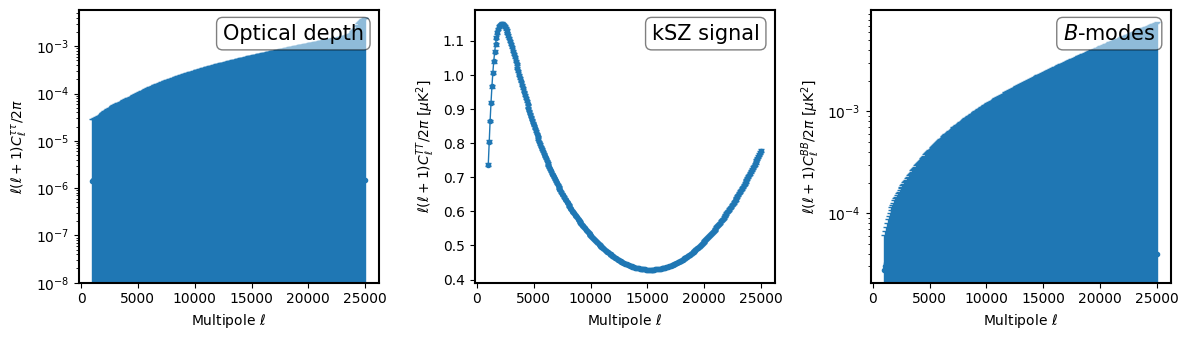

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=False)

# tau
axes[0].errorbar(
    ells[0], tau_data, yerr=np.sqrt(np.diag(cov_tau)),
    lw=1., marker='.', capsize=2.)
axes[0].set_xlabel(r'Multipole $\ell$')
axes[0].set_ylabel(r'$\ell(\ell+1)C_\ell^{\tau\tau}/2\pi$')
axes[0].set_yscale('log')
# axes[0].set_xlim(0, 10000)
axes[0].set_ylim(bottom=1e-8)
# axes[0].set_xlim(ells.min(), ells.max())

# ksz
axes[1].errorbar(
    ells[1], ksz_data, yerr=np.sqrt(np.diag(cov_ksz)),
    lw=1., marker='.', capsize=2.)
axes[1].set_xlabel(r'Multipole $\ell$')
axes[1].set_ylabel(r'$\ell(\ell+1)C_\ell^{TT}/2\pi$ [$\mu$K$^2$]')
# axes[1].set_xlim(ells.min(), 10000)
# axes[1].set_ylim(bottom=1e-2)
# axes[1].set_yscale('log')

# B-modes
axes[2].errorbar(
    ells[2], bb_data, yerr=np.sqrt(np.diag(cov_bb)),
    lw=1., marker='.', capsize=2.)
axes[2].set_xlabel(r'Multipole $\ell$')
axes[2].set_ylabel(r'$\ell(\ell+1)C_\ell^{BB}/2\pi$ [$\mu$K$^2$]')
# axes[2].set_ylim(bottom=1e-6)
# axes[2].set_xlim(low_ells.min(), low_ells.max())
axes[2].set_yscale('log')
# axes[2].set_xscale('log')

for i, (letter, title) in enumerate(zip(['a', 'b', 'c'],
                                        ['Optical depth', 'kSZ signal', r'$B$-modes'])):
    axes[i].text(0.95, 0.95, title, transform=axes[i].transAxes, fontsize=15, bbox=props, ha='right', va='top')
fig.tight_layout()
# fig.savefig('figures/fisher_forecast_ideal_data.pdf', dpi=220)

## MCMC

In [17]:
filename = f'backends/mcmc_{label}_backend'
if filename.find('wtau') > -1:
    tau_prior = True
else:
    tau_prior = False
print(tau_prior)

False


In [18]:
priors = [(5., 10.), (0.1, 4.5), (2.5, 4.5), (0.05, 0.4)]
ndim = len(priors)

In [19]:
sampler = emcee.backends.HDFBackend(f'{filename}.h5', read_only=True)
samples = sampler.get_chain(flat=False)
like = sampler.get_log_prob(flat=False)
print(samples.shape)

(16732, 8, 4)


In [20]:
# auto-correlation analysis to assess convergence and define burn-in
taus = sampler.get_autocorr_time(tol=0)
if np.isnan(taus).any():
	print('NaN tau. Taking max.')
endtau = np.nanmax(taus)
converged = np.all(taus * 60 < sampler.iteration)
print('Auto-correlation time: %.2f. Converged: %s.' %(endtau, converged))
burnin = int(max(0.1*samples.shape[0], 2.*np.max(taus)))
print(f'burnin = {burnin} ({burnin/samples.shape[0]:.1f}%)')

Auto-correlation time: 723.96. Converged: False.
burnin = 1673 (0.1%)


In [21]:
niter = samples.shape[0] #number of iterations performed, per walker
nwalkers = samples.shape[1]
nsamples = niter*nwalkers

(120472, 4)


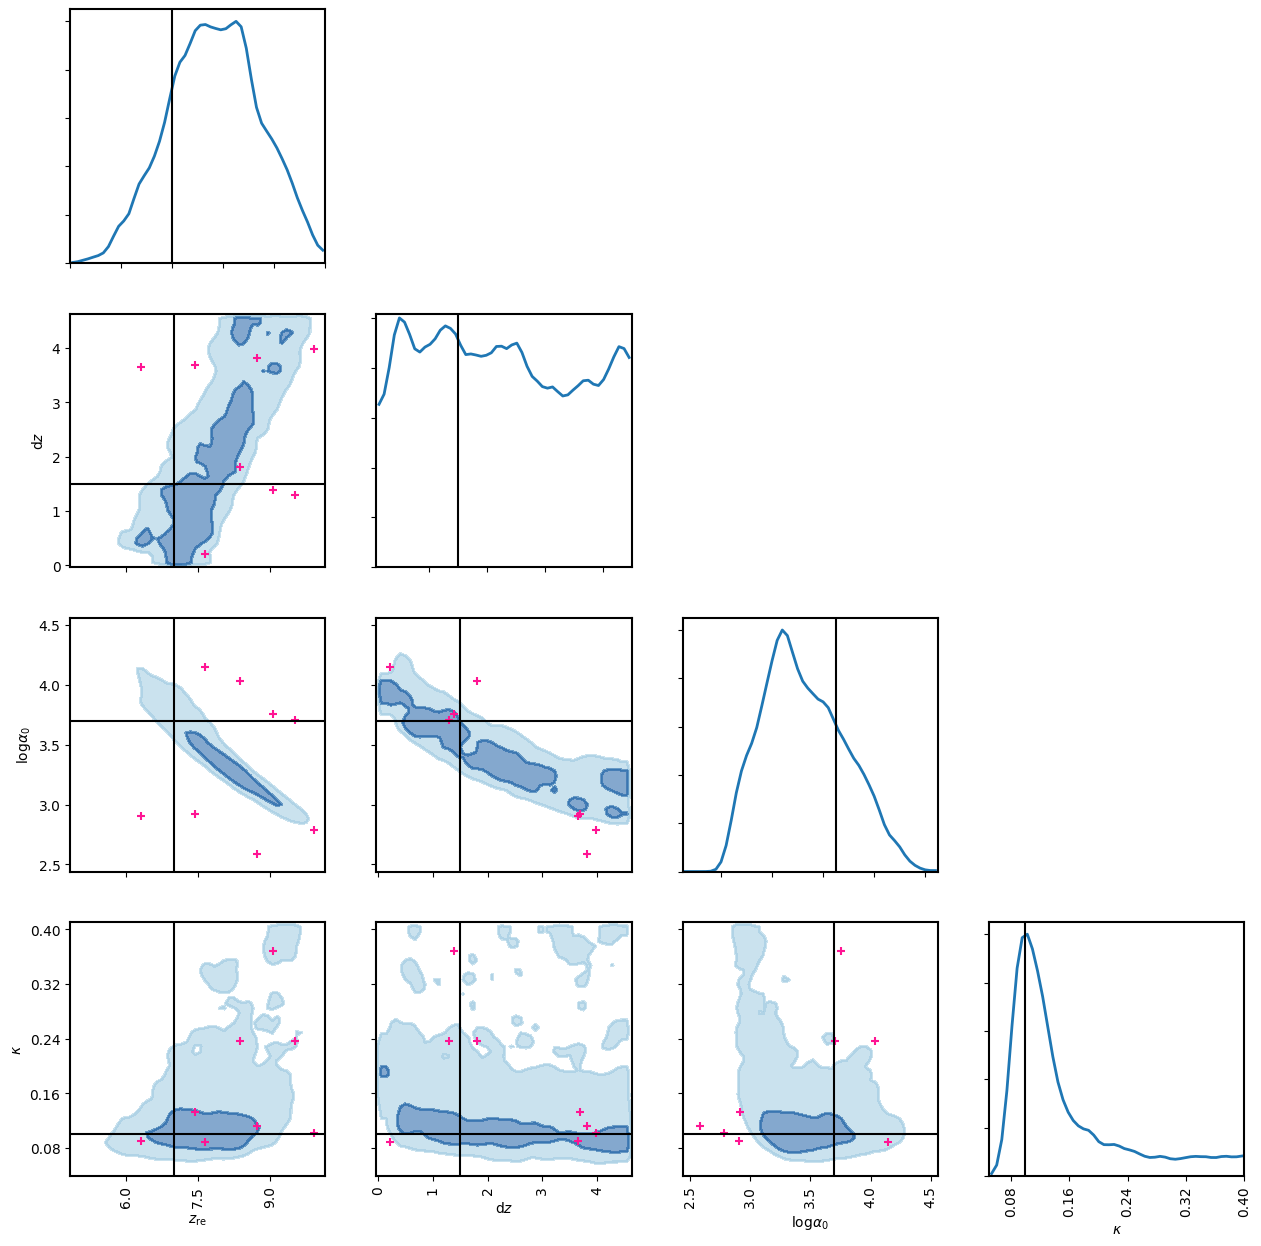

In [22]:
flatsamples = sampler.get_chain(flat=True, discard=burnin)
logps = sampler.get_log_prob(flat=True, discard=burnin)
print(flatsamples.shape)
bounds = priors.copy()
labels = theta_labels.copy()
truths = theta_true.copy()
if tau_prior:
    tau_samples = sampler.get_blobs(flat=True, discard=burnin)['tau']
    flatsamples = np.c_[flatsamples, tau_samples]
    bounds += [(0.045, 0.085)]
    labels += [r'$\tau$']
    truths += [preion_true.tau]

fig = triangleme.corner(
    flatsamples,
    truths=truths,
    labels=labels, truth_color='k',
    sigmas=[1, 2], plot_datapoints=False, 
    cmap='Blues', color='C0', 
    extents=bounds, normmax=True,
    lw=2., smooth=1.,

)
axes = np.reshape(fig.axes, (ndim, ndim))
for i in range(len(labels)):
    for j in range(len(labels)):
        if i > j:
            axes[i, j].scatter(samples[0, :, j], samples[0, :, i], marker='+', color='deeppink')
if tau_prior:
    x0 = np.linspace(0.04, 0.085, 500)
    gg = np.exp(-(x0-preion_true.tau)**2/2./0.007**2)/np.sqrt(2.*np.pi)
    gg = gg/np.max(gg)
    axes[-1, -1].plot(
        x0, gg, color='k', lw=2.,
        ls='--', label='Prior', alpha=.8,
        zorder=0
    )


# for i in range(1, ndim):       # Loop over rows (starting at 1 to skip diagonal)
#     for j in range(i):         # Loop over columns (lower triangle only)
#         axes[i,j].scatter(p0[:, j], p0[:, i], color='red', s=10, alpha=0.5)

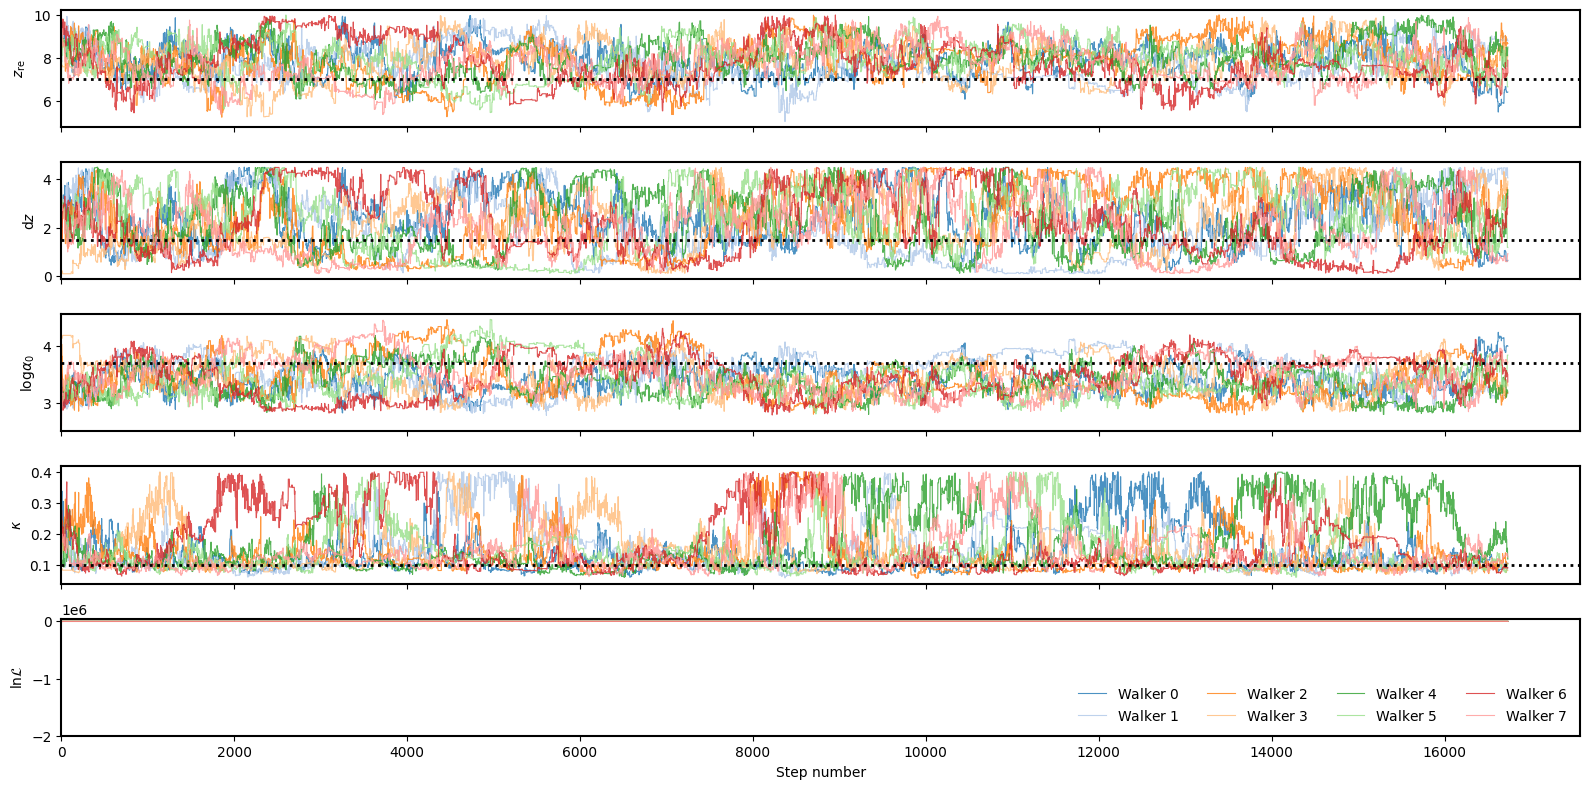

In [27]:
fig, axes = plt.subplots(ndim+1, figsize=(ndim*4, ndim*2), sharex=True)
for i in range(ndim):
    ax = axes[i]
    for j in range(nwalkers):
        ax.plot(samples[:, j, i], alpha=0.8, lw=.8, color=colorlist[j], label=rf'Walker ${j}$')
    ax.set_xlim(left=0)
    ax.set_ylabel(theta_labels[i])
    ax.axhline(theta_true[i], color='k', ls=':', lw=2.)
for j in range(nwalkers):
    axes[-1].plot(like[:, j], alpha=0.8, color=colorlist[j], label=rf'Walker ${j}$', lw=.8)
axes[-1].set_ylabel(r'ln$\mathcal{L}$')
axes[-1].legend(ncol=4, frameon=False, loc='lower right')
axes[-1].set_xlabel("Step number")
axes[-1].set_ylim(-2e6, 5e4)
# axes[-1].set_xlim(0, 200)
plt.tight_layout()

(16732, 8, 14)


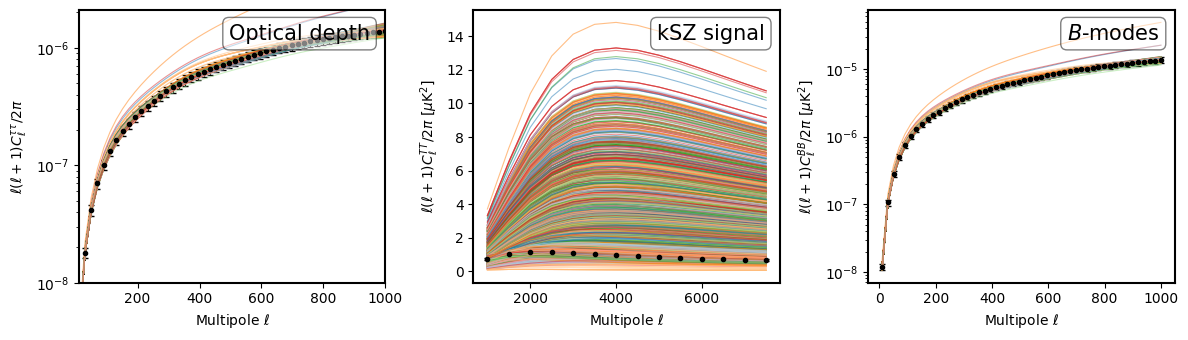

In [24]:
tau_models = sampler.get_blobs(flat=False)['tau_models']
ksz_models = sampler.get_blobs(flat=False)['ksz_models']
bb_models = sampler.get_blobs(flat=False)['bb_models']

print(ksz_models.shape)

nrand = min(500, tau_models.shape[0])
inds = np.random.choice(np.arange(ksz_models.shape[0]), size=nrand, replace=False)
# np.r_[ksz_ps, tau_ps, bb_ps]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=False)

# tau
axes[0].errorbar(
    ells[0], tau_data, yerr=np.sqrt(np.diag(cov_tau)),
    lw=0., elinewidth=.8, marker='.', capsize=2., color='k')
axes[0].set_xlabel(r'Multipole $\ell$')
axes[0].set_ylabel(r'$\ell(\ell+1)C_\ell^{\tau\tau}/2\pi$')
axes[0].set_yscale('log')
# axes[0].set_xlim(0, 10000)
axes[0].set_ylim(bottom=1e-8)
axes[0].set_xlim(ells[0].min(), ells[0].max())

# ksz
axes[1].errorbar(
    ells[1], ksz_data, yerr=np.sqrt(np.diag(cov_ksz)),
    lw=0., elinewidth=.8, marker='.', capsize=2., color='k')
axes[1].set_xlabel(r'Multipole $\ell$')
axes[1].set_ylabel(r'$\ell(\ell+1)C_\ell^{TT}/2\pi$ [$\mu$K$^2$]')
# axes[1].set_xlim(ells.min(), 10000)
# axes[1].set_ylim(bottom=1e-2)
# axes[1].set_yscale('log')

# B-modes
axes[2].errorbar(
    ells[2], bb_data, yerr=np.sqrt(np.diag(cov_bb)),
    lw=0., elinewidth=.8, marker='.', capsize=2., color='k')
axes[2].set_xlabel(r'Multipole $\ell$')
axes[2].set_ylabel(r'$\ell(\ell+1)C_\ell^{BB}/2\pi$ [$\mu$K$^2$]')
# axes[2].set_ylim(bottom=1e-6)
# axes[2].set_xlim(low_ells.min(), low_ells.max())
axes[2].set_yscale('log')
# axes[2].set_xscale('log')

for i in inds:
    for j in range(nwalkers):
        axes[0].plot(ells[0], tau_models[i, j, :], color=colorlist[j], lw=.8, alpha=.5)
        axes[1].plot(ells[1], ksz_models[i, j, :], color=colorlist[j], lw=.8, alpha=.5)
        axes[2].plot(ells[2], bb_models[i, j, :], color=colorlist[j], lw=.8, alpha=.5)

for i, (letter, title) in enumerate(zip(['a', 'b', 'c'],
                                        ['Optical depth', 'kSZ signal', r'$B$-modes'])):
    axes[i].text(0.95, 0.95, title, transform=axes[i].transAxes, fontsize=15, bbox=props, ha='right', va='top')
fig.tight_layout()
# fig.savefig('figures/fisher_forecast_ideal_data.pdf', dpi=220)

In [25]:
samples[0, :, -1]

array([0.36906483, 0.13337454, 0.23723728, 0.08961673, 0.10259086,
       0.08997669, 0.2364092 , 0.11223429])

0
1
2
3
4
5
6
7


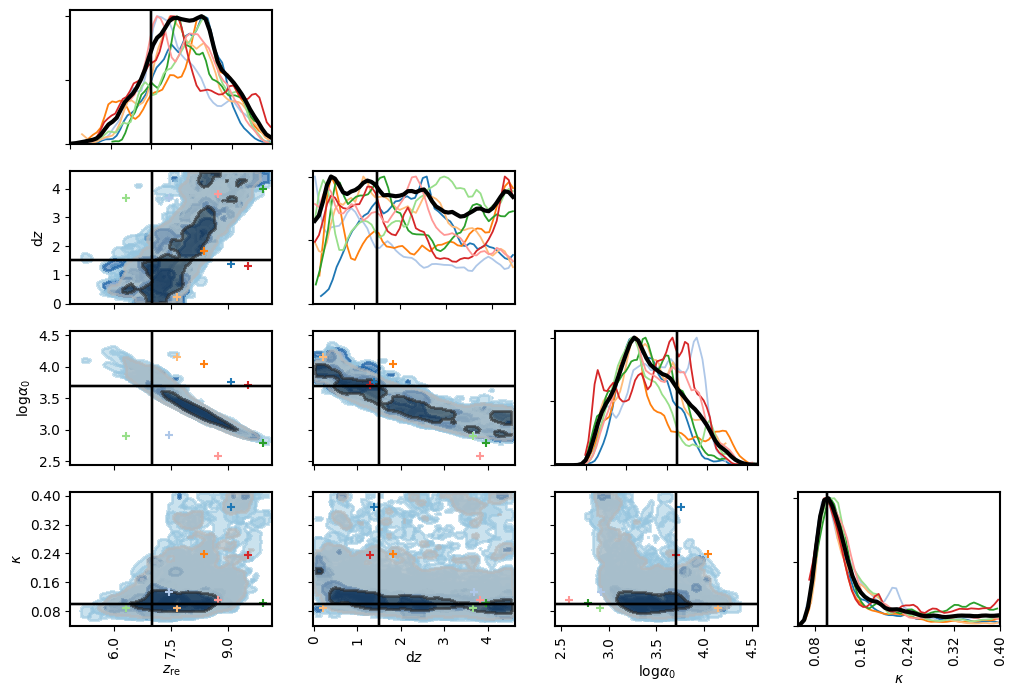

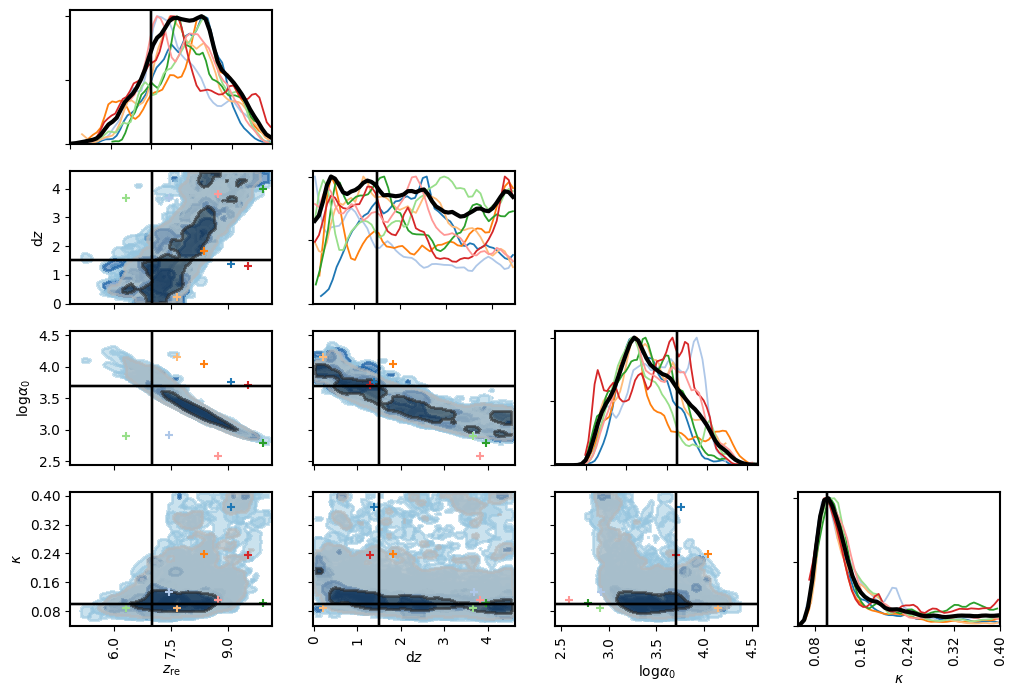

In [ ]:
fig, axes = plt.subplots(ndim, ndim, figsize=(12, 8))
for iw in range(nwalkers):
    print(iw)
    triangleme.corner(
        samples[:, iw, :],
        truths=truths,
        labels=labels, truth_color='k',
        sigmas=[1, 2], plot_datapoints=False, 
        cmap='Blues', color=colorlist[iw], 
        # extents=bounds, 
        normmax=True,
        lw=1.3, smooth=1., fig=fig,

    )
    for i in range(len(labels)):
        for j in range(len(labels)):
            if i > j:
                axes[i, j].scatter(samples[0, iw, j], samples[0, iw, i], marker='+', color=colorlist[iw])
_ = triangleme.corner(
    flatsamples,
    labels=labels, 
    sigmas=[1, 2], plot_datapoints=False, 
    cmap='Greys', color='k', 
    extents=bounds, normmax=True,
    lw=3., smooth=1., fig=fig, zorder=0,

)


In [ ]:
preion_model = Pee_model(
    h=cos.h, Ob_0=cos.Ob0, Om_0=cos.Om0,
    verbose=False, run_camb=True,
    use_ksz_emulator='NN')
preion_model.run_camb = False

preion_model2 = Pee_model(
    h=cos.h, Ob_0=cos.Ob0, Om_0=cos.Om0,
    verbose=False, run_camb=True,
    use_ksz_emulator='RF')
preion_model2.run_camb = False

In [ ]:
def get_model(theta, ells=ells):

    preion_model.zre_h = theta[0]
    preion_model.dz_h = theta[1]
    preion_model.alpha0 = theta[2]
    preion_model.kappa = theta[3]
    preion_model.init_reionisation_history()

    tau_ps = preion_model.get_tau(ells=ells[0], signal='both', Dells=True).sum(axis=1)
    ksz_ps = preion_model.get_ksz(ells=ells[1], signal='patchy', Dells=True)[:, 0]
    total_bb = preion_model.get_B_modes(ells=ells[2], Dells=True)

    return tau_ps, ksz_ps, total_bb

In [ ]:
def get_model_test(theta, ells=ells):

    preion_model.zre_h = theta[0]
    preion_model.dz_h = theta[1]
    preion_model.alpha0 = theta[2]
    preion_model.kappa = theta[3]
    preion_model.init_reionisation_history()


    preion_model2.zre_h = theta[0]
    preion_model2.dz_h = theta[1]
    preion_model2.alpha0 = theta[2]
    preion_model2.kappa = theta[3]
    preion_model2.init_reionisation_history()

    ksz_ps = preion_model.get_ksz(ells=ells[1], signal='patchy', Dells=True)[:, 0]
    ksz_ps2 = preion_model2.get_ksz(ells=ells[1], signal='patchy', Dells=True)[:, 0]

    return ksz_ps, ksz_ps2

In [ ]:
samples[0, :, :], theta_true

In [ ]:
ii = np.random.randint(samples.shape[0])

plt.figure()
plt.plot(ells[1], ksz_models[ii, 2, :], marker='.', label='backend')
plt.plot(ells[1], get_model_test(samples[ii, 2, :])[1], label='computed RF')
plt.plot(ells[1], get_model_test(samples[ii, 2, :])[0], label='computed NN')
plt.plot(ells[1], ksz_data, marker='.', label='Data', color='k')
print(like[ii, 2])
# plt.plot(ells[1], b, label='RF', ls='--')
plt.legend()

In [ ]:
a,b = get_model_test(theta_true)

plt.figure()
plt.plot(ells[1], ksz_data, marker='.', label='Data with RF')
plt.plot(ells[1], a, label='NN')
plt.plot(ells[1], b, label='RF', ls='--')
plt.legend()

In [ ]:
def lnlike(model):
    tau_ps, ksz_ps, bb_ps = model
    tau_like = (tau_ps - tau_data).T.dot(np.linalg.inv(cov_tau)).dot(tau_ps - tau_data)
    ksz_like = (ksz_ps - ksz_data).T.dot(np.linalg.inv(cov_ksz)).dot(ksz_ps - ksz_data)
    bb_like = (bb_ps - bb_data).T.dot(np.linalg.inv(cov_bb)).dot(bb_ps - bb_data)
    return -0.5 * tau_like, -0.5 * ksz_like, -0.5 * bb_like, -0.5*(tau_like + ksz_like + bb_like)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=False)

# tau
axes[0].errorbar(
    ells[0], tau_data, yerr=np.sqrt(np.diag(cov_tau)),
    lw=0., elinewidth=.8, marker='.', capsize=2., color='k')
axes[0].set_xlabel(r'Multipole $\ell$')
axes[0].set_ylabel(r'$\ell(\ell+1)C_\ell^{\tau\tau}/2\pi$')
axes[0].set_yscale('log')
# axes[0].set_xlim(0, 10000)
axes[0].set_ylim(bottom=1e-8)
axes[0].set_xlim(ells[0].min(), ells[0].max())

# ksz
axes[1].errorbar(
    ells[1], ksz_data, yerr=np.sqrt(np.diag(cov_ksz)),
    lw=0., elinewidth=.8, marker='.', capsize=2., color='k')
axes[1].set_xlabel(r'Multipole $\ell$')
axes[1].set_ylabel(r'$\ell(\ell+1)C_\ell^{TT}/2\pi$ [$\mu$K$^2$]')
# axes[1].set_xlim(ells.min(), 10000)
# axes[1].set_ylim(bottom=1e-2)
# axes[1].set_yscale('log')

# B-modes
axes[2].errorbar(
    ells[2], bb_data, yerr=np.sqrt(np.diag(cov_bb)),
    lw=0., elinewidth=.8, marker='.', capsize=2., color='k')
axes[2].set_xlabel(r'Multipole $\ell$')
axes[2].set_ylabel(r'$\ell(\ell+1)C_\ell^{BB}/2\pi$ [$\mu$K$^2$]')
# axes[2].set_ylim(bottom=1e-6)
# axes[2].set_xlim(low_ells.min(), low_ells.max())
axes[2].set_yscale('log')
# axes[2].set_xscale('log')

for j in range(nwalkers):
    axes[0].plot(ells[0], np.mean(tau_models[:, j, :], axis=0), color=colorlist[j], label=f'Walker {j}')
    axes[1].plot(ells[1], np.mean(ksz_models[:, j, :], axis=0), color=colorlist[j], label=f'Walker {j}')
    axes[2].plot(ells[2], np.mean(bb_models[:, j, :], axis=0), color=colorlist[j], label=f'Walker {j}')
    print(j, lnlike([np.mean(tau_models[:, j, :], axis=0), np.mean(ksz_models[:, j, :], axis=0), np.mean(bb_models[:, j, :], axis=0)]))
axes[1].legend(ncol=2, fontsize=9, frameon=False)
for i, (letter, title) in enumerate(zip(['a', 'b', 'c'],
                                        ['Optical depth', 'kSZ signal', r'$B$-modes'])):
    axes[i].text(0.95, 0.95, title, transform=axes[i].transAxes, fontsize=15, bbox=dict(boxstyle="round", facecolor="white"), ha='right', va='top')
fig.tight_layout()
# fig.savefig('figures/fisher_forecast_ideal_data.pdf', dpi=220)

In [ ]:
nwalkers

In [ ]:
ichain = 0

samples2 = sampler.get_chain(flat=False, discard=burnin)
samples2 = samples2[:, ichain, :]
flatsamples2 = samples2.reshape(-1, samples2.shape[-1])
print(flatsamples2.shape)

plt.hist(flatsamples2[:, 0], bins=50, histtype='stepfilled', color='C0', alpha=.5)

fig = triangleme.corner(
    flatsamples2,
    truths=truths,
    labels=labels, truth_color='k',
    sigmas=[1, 2], plot_datapoints=False, 
    cmap='Blues', color='C0', 
    # extents=bounds, 
    normmax=True,
    lw=2., smooth=1.,

)

tau_models = sampler.get_blobs(flat=False, discard=burnin)['tau_models'][:, ichain, :]
ksz_models = sampler.get_blobs(flat=False, discard=burnin)['ksz_models'][:, ichain, :]
bb_models = sampler.get_blobs(flat=False, discard=burnin)['bb_models'][:, ichain, :]

print(ksz_models.shape)

nrand = 500
inds = np.random.choice(np.arange(ksz_models.shape[0]), size=nrand, replace=False)
# np.r_[ksz_ps, tau_ps, bb_ps]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=False)

# tau
axes[0].errorbar(
    ells[0], tau_data, yerr=np.sqrt(np.diag(cov_tau)),
    lw=0., elinewidth=.8, marker='.', capsize=2., color='k')
axes[0].set_xlabel(r'Multipole $\ell$')
axes[0].set_ylabel(r'$\ell(\ell+1)C_\ell^{\tau\tau}/2\pi$')
axes[0].set_yscale('log')
# axes[0].set_xlim(0, 10000)
axes[0].set_ylim(bottom=1e-8)
axes[0].set_xlim(ells[0].min(), ells[0].max())

# ksz
axes[1].errorbar(
    ells[1], ksz_data, yerr=np.sqrt(np.diag(cov_ksz)),
    lw=0., elinewidth=.8, marker='.', capsize=2., color='k')
axes[1].set_xlabel(r'Multipole $\ell$')
axes[1].set_ylabel(r'$\ell(\ell+1)C_\ell^{TT}/2\pi$ [$\mu$K$^2$]')
# axes[1].set_xlim(ells.min(), 10000)
# axes[1].set_ylim(bottom=1e-2)
# axes[1].set_yscale('log')

# B-modes
axes[2].errorbar(
    ells[2], bb_data, yerr=np.sqrt(np.diag(cov_bb)),
    lw=0., elinewidth=.8, marker='.', capsize=2., color='k')
axes[2].set_xlabel(r'Multipole $\ell$')
axes[2].set_ylabel(r'$\ell(\ell+1)C_\ell^{BB}/2\pi$ [$\mu$K$^2$]')
# axes[2].set_ylim(bottom=1e-6)
# axes[2].set_xlim(low_ells.min(), low_ells.max())
axes[2].set_yscale('log')
# axes[2].set_xscale('log')

for i in inds:
    axes[0].plot(ells[0], tau_models[i], color='C0', lw=.8, alpha=.5)
    axes[1].plot(ells[1], ksz_models[i], color='C0', lw=.8, alpha=.5)
    axes[2].plot(ells[2], bb_models[i], color='C0', lw=.8, alpha=.5)

for i, (letter, title) in enumerate(zip(['a', 'b', 'c'],
                                        ['Optical depth', 'kSZ signal', r'$B$-modes'])):
    axes[i].text(0.95, 0.95, title, transform=axes[i].transAxes, fontsize=15, bbox=props, ha='right', va='top')
fig.tight_layout()
# fig.savefig('figures/fisher_forecast_ideal_data.pdf', dpi=220)

(17446, 7, 4)
(17446, 7, 14)


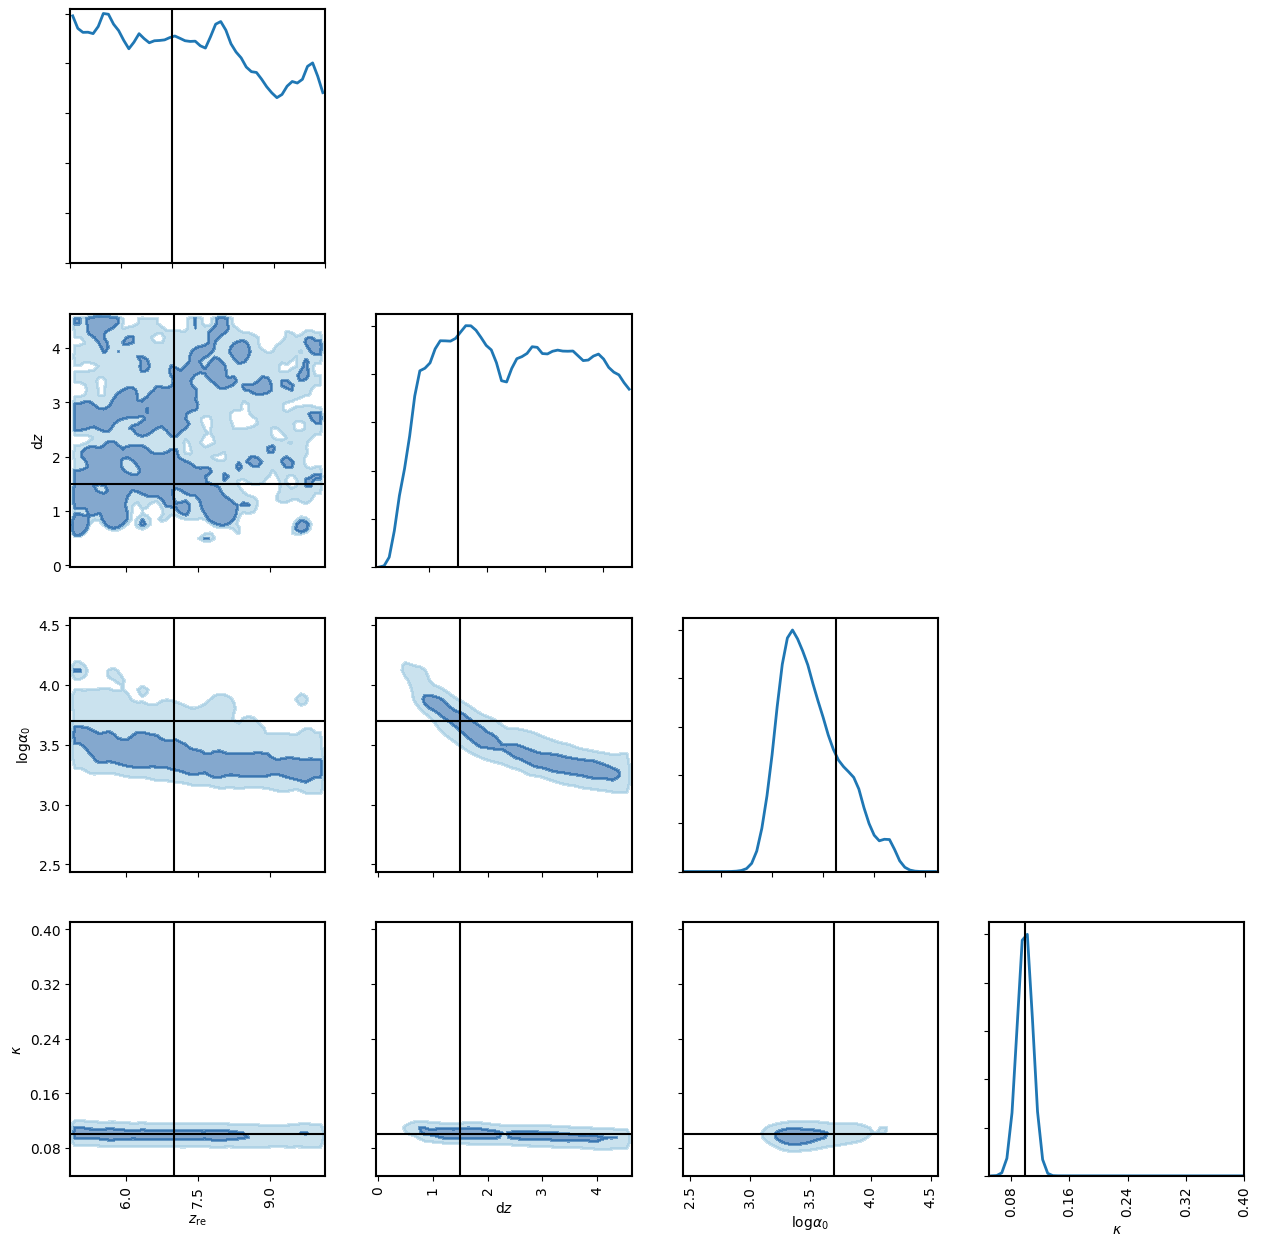

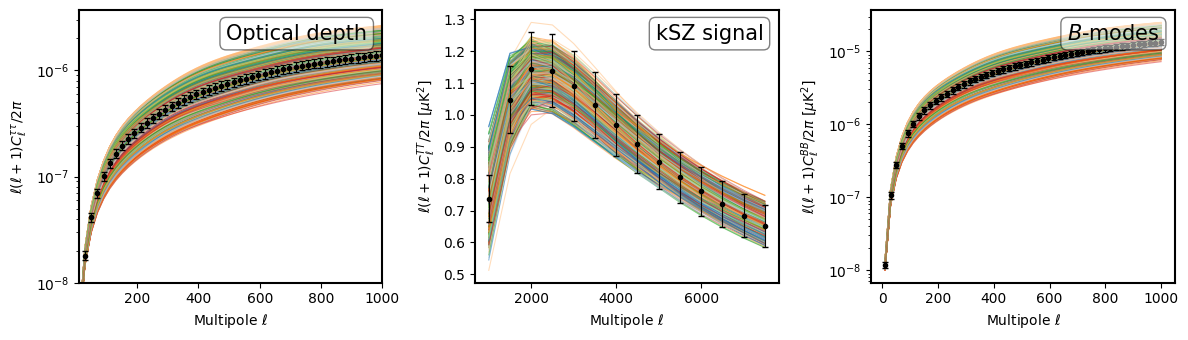

In [25]:
walkers_to_remove = [6]

samples2 = sampler.get_chain(flat=False, discard=burnin)
samples2 = np.delete(samples2, walkers_to_remove, axis=1)  #samples2[:, [0, 1, 5], :]
print(samples2.shape)
# flatsamples2 = samples2.reshape(-1, samples2.shape[-1])
# print(flatsamples2.shape)

fig = triangleme.corner(
    samples2.reshape(-1, samples2.shape[-1]),
    truths=truths,
    labels=labels, truth_color='k',
    sigmas=[1, 2], plot_datapoints=False, 
    cmap='Blues', color='C0', 
    extents=bounds, normmax=True,
    lw=2., smooth=1.,
)

tau_models = np.delete(sampler.get_blobs(flat=False, discard=burnin)['tau_models'], walkers_to_remove, axis=1)
ksz_models = np.delete(sampler.get_blobs(flat=False, discard=burnin)['ksz_models'], walkers_to_remove, axis=1)
bb_models = np.delete(sampler.get_blobs(flat=False, discard=burnin)['bb_models'], walkers_to_remove, axis=1)
print(ksz_models.shape)

nrand = 500
inds = np.random.choice(np.arange(ksz_models.shape[0]), size=nrand, replace=False)
# np.r_[ksz_ps, tau_ps, bb_ps]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=False)

for i in inds:
    for j in range(ksz_models.shape[1]):
        axes[0].plot(ells[0], tau_models[i, j, :], color=colorlist[j], lw=.8, alpha=.5)
        axes[1].plot(ells[1], ksz_models[i, j, :], color=colorlist[j], lw=.8, alpha=.5)
        axes[2].plot(ells[2], bb_models[i, j, :], color=colorlist[j], lw=.8, alpha=.5)

# tau
axes[0].errorbar(
    ells[0], tau_data, yerr=np.sqrt(np.diag(cov_tau)),
    lw=0., elinewidth=.8, marker='.', capsize=2., color='k')
axes[0].set_xlabel(r'Multipole $\ell$')
axes[0].set_ylabel(r'$\ell(\ell+1)C_\ell^{\tau\tau}/2\pi$')
axes[0].set_yscale('log')
# axes[0].set_xlim(0, 10000)
axes[0].set_ylim(bottom=1e-8)
axes[0].set_xlim(ells[0].min(), ells[0].max())

# ksz
axes[1].errorbar(
    ells[1], ksz_data, yerr=np.sqrt(np.diag(cov_ksz)),
    lw=0., elinewidth=.8, marker='.', capsize=2., color='k')
axes[1].set_xlabel(r'Multipole $\ell$')
axes[1].set_ylabel(r'$\ell(\ell+1)C_\ell^{TT}/2\pi$ [$\mu$K$^2$]')
# axes[1].set_xlim(ells.min(), 10000)
# axes[1].set_ylim(bottom=1e-2)
# axes[1].set_yscale('log')

# B-modes
axes[2].errorbar(
    ells[2], bb_data, yerr=np.sqrt(np.diag(cov_bb)),
    lw=0., elinewidth=.8, marker='.', capsize=2., color='k')
axes[2].set_xlabel(r'Multipole $\ell$')
axes[2].set_ylabel(r'$\ell(\ell+1)C_\ell^{BB}/2\pi$ [$\mu$K$^2$]')
# axes[2].set_ylim(bottom=1e-6)
# axes[2].set_xlim(low_ells.min(), low_ells.max())
axes[2].set_yscale('log')
# axes[2].set_xscale('log')

for i, (letter, title) in enumerate(zip(['a', 'b', 'c'],
                                        ['Optical depth', 'kSZ signal', r'$B$-modes'])):
    axes[i].text(0.95, 0.95, title, transform=axes[i].transAxes, fontsize=15, bbox=props, ha='right', va='top')
fig.tight_layout()
# fig.savefig('figures/fisher_forecast_ideal_data.pdf', dpi=220)

In [ ]:
# remove walker 0
iw = 0
samples2 = sampler.get_chain(flat=False, discard=burnin)

bounds = priors.copy()
labels = theta_labels.copy()
truths = theta_true.copy()
if tau_prior:
    tau_samples = sampler.get_blobs(flat=True, discard=burnin)['tau']
    flatsamples = np.c_[flatsamples, tau_samples]
    bounds += [(0.045, 0.085)]
    labels += [r'$\tau$']
    truths += [preion_true.tau]

fig = triangleme.corner(
    flatsamples,
    truths=truths,
    labels=labels, truth_color='k',
    sigmas=[1, 2], plot_datapoints=False, 
    cmap='Blues', color='C0', 
    extents=bounds, normmax=True,
    lw=2., smooth=1.,

)
if tau_prior:
    x0 = np.linspace(0.04, 0.085, 500)
    gg = np.exp(-(x0-preion_true.tau)**2/2./0.007**2)/np.sqrt(2.*np.pi)
    gg = gg/np.max(gg)
    axes = np.asarray(fig.axes)  # Access all the axes in the corner plot
    axes = axes.reshape(np.size(truths), np.size(truths))
    axes[-1, -1].plot(
        x0, gg, color='k', lw=2.,
        ls='--', label='Prior', alpha=.8,
        zorder=0
    )


# for i in range(1, ndim):       # Loop over rows (starting at 1 to skip diagonal)
#     for j in range(i):         # Loop over columns (lower triangle only)
#         axes[i,j].scatter(p0[:, j], p0[:, i], color='red', s=10, alpha=0.5)

In [ ]:
cov = np.cov(flatsamples.T)
corrcoef = np.corrcoef(flatsamples.T)

fom = np.sqrt(np.linalg.det(cov))
print(fom)

In [ ]:
fig, ax = plt.subplots()
im = ax.imshow(corrcoef, cmap='coolwarm', #norm=colors.LogNorm(),
            extent=(0, 2, 2, 0),vmax=1, vmin=-1)
ax.set_xticks(np.arange(0.25, 2, step=.5),
            labels=theta_labels, fontsize=14)
ax.set_yticks(np.arange(0.25, 2, step=.5),
            labels=theta_labels, fontsize=14)
cbar = plt.colorbar(im, fraction=0.045, ax=ax, label=r'$\mathcal{C}_{ij}$')
